### Simulations

In [2]:
import numpy as np
import networkx as nx
import random
import torch
import torch.nn as nn
from torch_geometric.data import Data
from sklearn.metrics import adjusted_rand_score
import random
from models import GEE, GNN
from time import time
import matplotlib.pyplot as plt
from scipy.stats import norm
from pathlib import Path  
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import umap

def generate_dc_sbm(n, k, pq, r, degree_dist="beta", params=(1, 4), balanced="True", seed=None):
    """
    Generates a graph according to the Degree-Corrected Stochastic Block Model (DC-SBM).

    In DC-SBM, the probability of an edge between node i and j is:
    P(i, j) = degree_params[i] * degree_params[j] * probs[labels[i], labels[j]]

    Args:
        n (int): Total number of nodes.
        k (int): Number of communities (blocks).
        pq (float): The base probability for intra-community edges (p).
        r (float): The base probability for inter-community edges (q).
        degree_dist (str, optional): The distribution for sampling degree parameters ('beta' or 'uniform').
        params (tuple, optional): The parameters for the chosen degree distribution.
        balanced (bool, optional): If True, communities have nearly equal sizes.
                                   If False, sizes are imbalanced based on a fixed ratio.
        seed (int, optional): Random seed for reproducibility.

    Returns:
        tuple: A tuple containing (networkx.Graph, numpy.ndarray) for the graph and labels.
    """
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    if balanced:
        block_sizes = [n // k] * k
        remainder = n - sum(block_sizes)
        for i in range(remainder):
            block_sizes[i] += 1

        labels = np.concatenate([[i] * block_sizes[i] for i in range(k)])
    else:
        ratio = np.array([1, 2, 3, 4], dtype=float)

        block_sizes = np.floor(ratio / ratio.sum() * n).astype(int)

        remainder = n - block_sizes.sum()
        block_sizes[:remainder] += 1         

        labels = np.concatenate([[i] * block_sizes[i] for i in range(k)])

    if degree_dist == "beta":
        degree_params = np.random.beta(params[0], params[1], size=n)
    elif degree_dist == "uniform":
        degree_params = np.random.uniform(params[0], params[1], size=n)
    else:
        raise ValueError("Unsupported degree distribution. Use 'beta' or 'uniform'.")
    G = nx.Graph()
    probs = np.full((k, k), r)
    np.fill_diagonal(probs, pq)

    for i in range(n):
        for j in range(i + 1, n):
            prob = probs[labels[i], labels[j]] * degree_params[i] * degree_params[j]
            if np.random.rand() < prob:
                G.add_edge(i, j)

    return G, labels

def generate_sbm(n, k, pq, r, balanced="True", seed=None):
    """
    Generates a graph according to the standard Stochastic Block Model (SBM).

    In SBM, the probability of an edge between node i and j depends only on their communities.
    P(i, j) = probs[labels[i], labels[j]]

    Args:
        n (int): Total number of nodes.
        k (int): Number of communities (blocks).
        pq (float): The probability for intra-community edges (p).
        r (float): The probability for inter-community edges (q).
        balanced (bool, optional): If True, communities have nearly equal sizes.
                                   If False, sizes are imbalanced based on a fixed ratio.
        seed (int, optional): Random seed for reproducibility.

    Returns:
        tuple: A tuple containing (networkx.Graph, numpy.ndarray) for the graph and labels.
    """
    if seed != None:
        np.random.seed(seed)
        random.seed(seed)
    
    if balanced:
        block_sizes = [n // k] * k
        remainder = n - sum(block_sizes)
        for i in range(remainder):
            block_sizes[i] += 1

        labels = np.concatenate([[i] * block_sizes[i] for i in range(k)])
    else:
        ratio = np.array([1, 2, 3, 4], dtype=float)

        block_sizes = np.floor(ratio / ratio.sum() * n).astype(int)

        remainder = n - block_sizes.sum()
        block_sizes[:remainder] += 1         

        labels = np.concatenate([[i] * block_sizes[i] for i in range(k)])

    G = nx.Graph()
    probs = np.full((k, k), r) 
    np.fill_diagonal(probs, pq) 

    for i in range(n):
        for j in range(i + 1, n):
            comm_i = labels[i]
            comm_j = labels[j]
            if np.random.rand() < probs[comm_i, comm_j]:
                G.add_edge(i, j)  

    return G, labels

def write(file_path, content, r):
    """
    Appends experiment results for a given run to a tab-separated file.

    Args:
        file_path (str): The path to the output file.
        content (dict): A dictionary mapping method names to their results.
        r (int): The inter-community probability.
    """
    with open(file_path, "a") as f:
        # f.write("r_value\tMethod\tARI_Results\n")
        for method, arr in content.items():
            arr = np.asarray(arr, dtype=float)
            # flat = arr.flatten()
            ari_str = ",".join(f"{x}" for x in arr)
            line = f"{r}\t{method}\t{ari_str}\n"
            f.write(line)

/opt/anaconda3/envs/gnn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def run(n, k, pq, r, flag="SBM", balanced = True, return_embdict=False):
    """  
        Generate SBM/DC-SBM
    """
    if flag == "SBM":
        G, Y = generate_sbm(n, k, pq, r, balanced= balanced)
    else:
        G, Y = generate_dc_sbm(n, k, pq, r, balanced= balanced) #this one
        # G, Y = generate_dc_sbm(n, k, pq, r, degree_dist="uniform", params=(0.01, 0.2))
    edge_list = [(u, v, 1) for u, v in G.edges()]
    labels = torch.tensor(Y, dtype=torch.long)
    edge_index = torch.tensor(list(G.edges), dtype=torch.long).t().contiguous()


    # --- Baseline 1: GEE ---
    st = time()
    model_GEE = GEE.UnSup_Gee(edge_list, n, k)
    Z_GEE, yhat = model_GEE.GEE_unsup()
    et = time()
    t_GEE = et - st
    ari_GEE = adjusted_rand_score(Y, yhat)
    print(f"GEE running time: {t_GEE}s, ARI: {ari_GEE:.4f}")


    # --- Baseline 2: GNN (initialized randomly) ---
    initializer = nn.init.xavier_uniform_
    # z = nn.Parameter(initializer(torch.empty(n, k)))
    z = initializer(torch.empty(n, k))
    data = Data(x=z, edge_index=edge_index, y=labels, k=k)
    st = time()
    ari_GNN, Z_GNN, Z_GNN_dict = GNN.gnn_clustering_with_dmon(data, labels=Y, return_embdict=return_embdict)
    et = time()
    t_GNN = et-st
    print(f"GNN running time: {t_GNN}s, ARI: {ari_GNN:.4f}")

    # --- Our Proposed Model: GEE-powered GNN (GG) ---
    z = torch.tensor(Z_GEE, dtype=torch.float)
    data.x = z  
    st = time()
    ari_GG, Z_GG, Z_GG_dict = GNN.gnn_clustering_with_dmon(data, labels=labels, return_embdict=return_embdict)
    et = time()
    t_GG = et - st
    print(f"GG running time: {t_GG:.4f}s, ARI: {ari_GG:.4f}")

    ari_t = ([ari_GEE, ari_GNN, ari_GG], [t_GEE, t_GNN, t_GG])
    Z_dict = Z_GNN_dict, Z_GG_dict
    return ari_t, Z_dict

In [8]:
# =============================================================================
# Main script for conducting the simulation study on SBM and DC-SBM graphs.
#
# This script systematically evaluates the performance of different models
# (GEE, GNN, GG) by varying the inter-community edge probability (`r`)
# and running multiple replications for each setting to ensure robustness.
# =============================================================================

torch.manual_seed(101)
random.seed(101)
np.random.seed(101)
n_reps = 50
flag = "DC_SBM"
if flag == "DC_SBM":
    n, k, pq, rvalues = 2000, 4, 0.3, np.arange(0, 0.305, 0.02) 
else:
    n, k, pq, rvalues = 800, 4, 0.15, np.arange(0.06, 0.151, 0.01) 

for r in rvalues:
    ari_all = {'GEE':[], 'GNN':[], "GG":[]}
    time_all = {'GEE':[], 'GNN':[], "GG":[]}
    for rep in range(50, 50+n_reps):
        ari_t, _ =  run(n, k, pq, r, flag=flag, balanced = False, return_embdict=False)
        ari_list, time_list= ari_t
        for i, m in enumerate(ari_all):
            ari_all[m].append(ari_list[i])
            time_all[m].append(time_list[i])

    write(f"results/{flag}/ari_{flag}_unbal.txt", ari_all, r)
    write(f"results/{flag}/time_{flag}_unbal.txt", time_all, r)

KeyboardInterrupt: 

GEE running time: 10.71647310256958s, ARI: 0.1519
GNN running time: 123.92419099807739s, ARI: 0.2590
GG running time: 46.5630s, ARI: 0.3272


/opt/anaconda3/envs/gnn/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


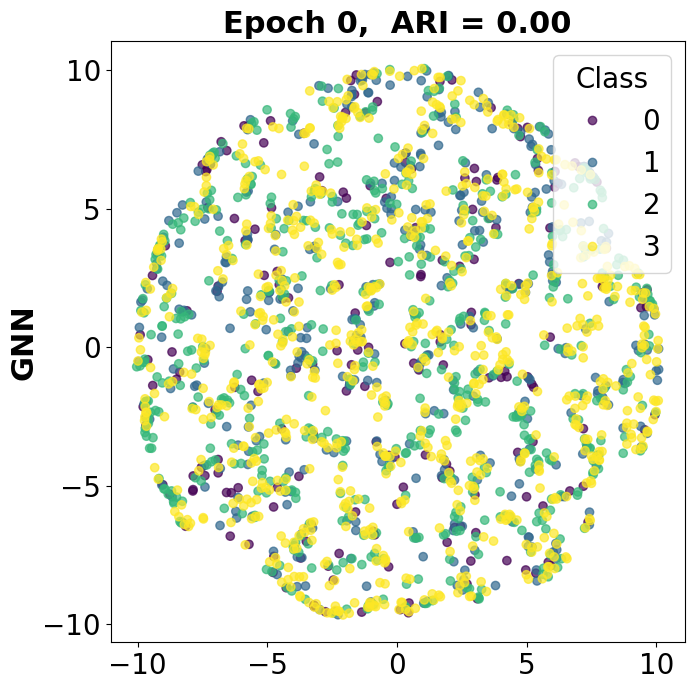

/opt/anaconda3/envs/gnn/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


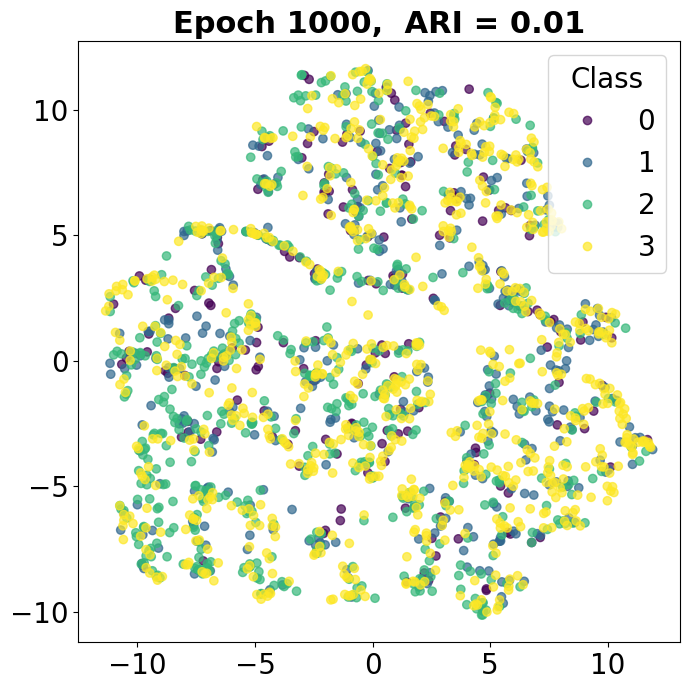

/opt/anaconda3/envs/gnn/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


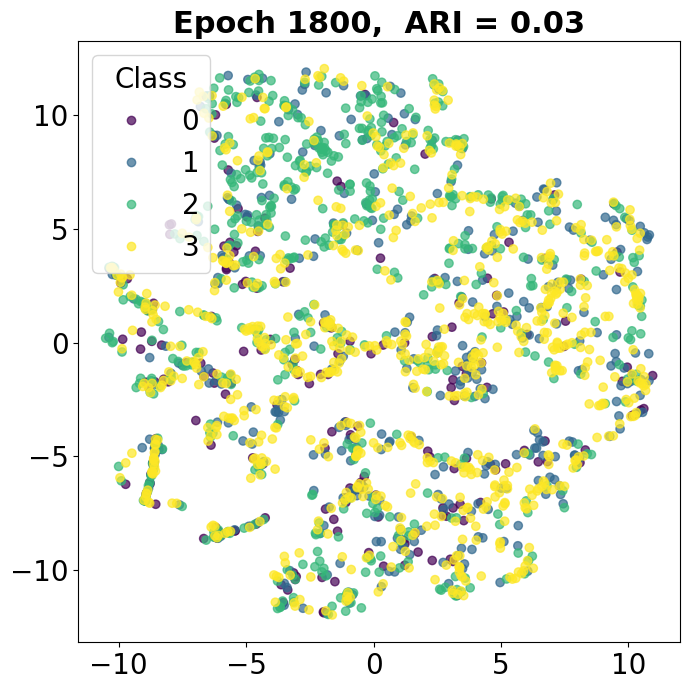

/opt/anaconda3/envs/gnn/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


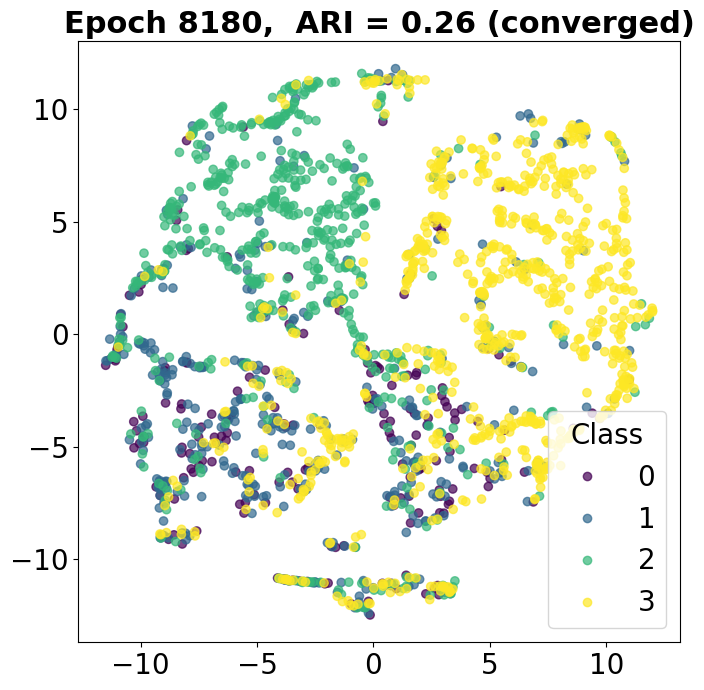

/opt/anaconda3/envs/gnn/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


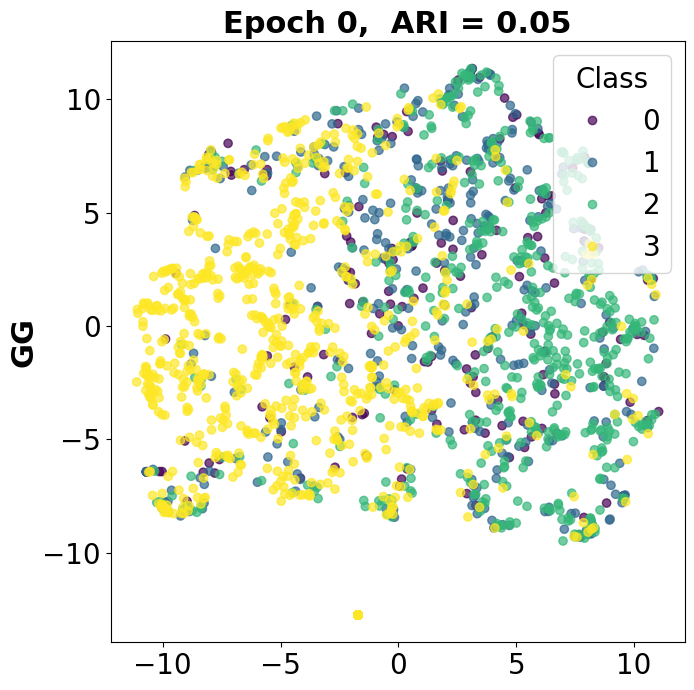

/opt/anaconda3/envs/gnn/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


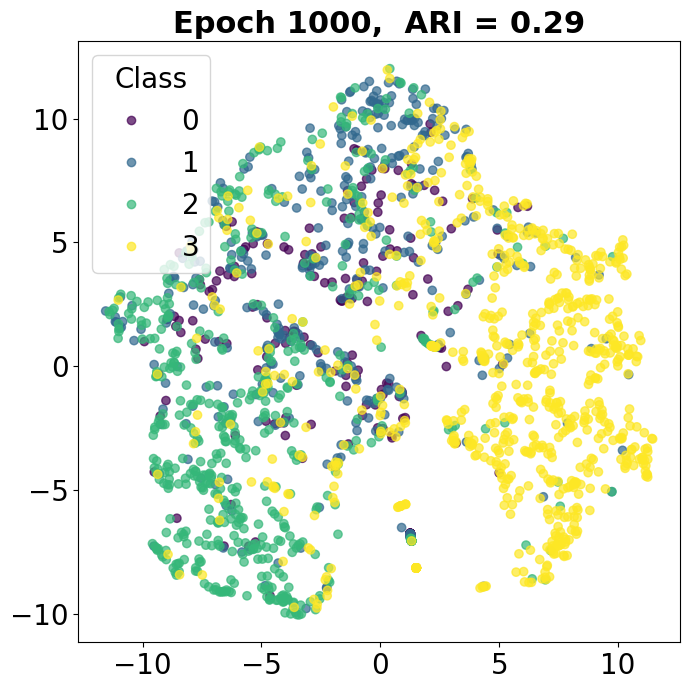

/opt/anaconda3/envs/gnn/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


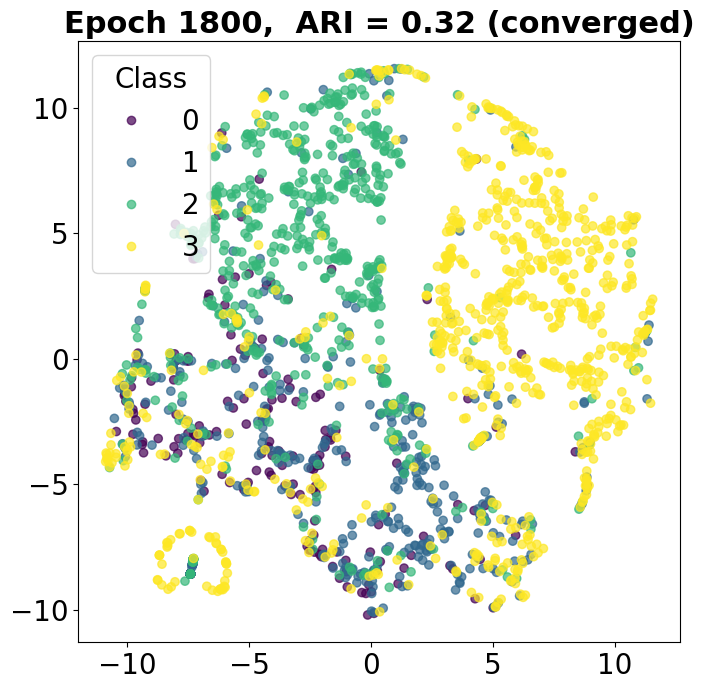

In [5]:
# =============================================================================
# Visualize the evolution of node embeddings using t-SNE.
# This generates and saves a series of plots for different epochs of the
# GNN and GG models on a DC-SBM graph.
# =============================================================================

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# --- 0. Global Setup: Plotting Styles and Seeds ---

# Set consistent font sizes for all plots for publication-quality figures.
plt.rcParams.update({
    "figure.titlesize": 22,
    "axes.titlesize": 22,
    "axes.labelsize": 24,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "legend.title_fontsize": 20
})

# Set global random seeds for general reproducibility.
torch.manual_seed(101)
random.seed(101)
np.random.seed(101)


# --- 1. Experiment Configuration ---

n = 2000         
k = 4          
pq = 0.30      
r = 0.1         
seed = 13        

torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

ratio = np.array([1, 2, 3, 4], dtype=float)
block_sizes = np.floor(ratio / ratio.sum() * n).astype(int)
remainder = n - block_sizes.sum()
block_sizes[:remainder] += 1
labels = np.concatenate([[i] * block_sizes[i] for i in range(k)])


# --- 2. Run the Model and Get Embeddings ---

_, Z_dict = run(n, k, pq, r, flag="DCSBM", balanced=False, return_embdict=True)
Z_GNN_dict, Z_GG_dict = Z_dict


# --- 3. Generate and Save t-SNE Visualizations ---

perplexity_value = min(30, n - 1)

for epoch, Z in Z_GNN_dict.items():
    yhat = torch.argmax(Z, dim=1)
    ari  = adjusted_rand_score(labels, yhat)

    Z2d = (TSNE(n_components=2, random_state=seed,
                perplexity=perplexity_value, n_iter=300)
            .fit_transform(Z.detach().cpu().numpy())
            if Z.shape[1] > 2 else Z.detach().cpu().numpy())

    plt.figure(figsize=(7, 7))
    if epoch != max(Z_GNN_dict):
        plt.title(f"Epoch {epoch},  ARI = {ari:.2f}", fontweight="bold")
    else:
        plt.title(f"Epoch {epoch},  ARI = {ari:.2f} (converged)", fontweight="bold")
    sc = plt.scatter(Z2d[:, 0], Z2d[:, 1], c=labels,
                        cmap="viridis", alpha=0.7)
    if epoch == 0:
        plt.text(-0.15, 0.5, "GNN", transform=plt.gca().transAxes,
                 rotation="vertical", ha="center", va="center",
                 fontsize=22, fontweight="bold")

    ticks = [-10, -5, 0, 5, 10]
    plt.xticks(ticks)
    plt.yticks(ticks)
    plt.legend(*sc.legend_elements(), title="Class", loc="best")
    plt.tight_layout()
    plt.savefig(f"epoch_{epoch}_GNN.png", dpi=300)
    plt.show()

for epoch, Z in Z_GG_dict.items():
    yhat = torch.argmax(Z, dim=1)
    ari  = adjusted_rand_score(labels, yhat)

    Z2d = (TSNE(n_components=2, random_state=seed,
                perplexity=perplexity_value, n_iter=300)
            .fit_transform(Z.detach().cpu().numpy())
            if Z.shape[1] > 2 else Z.detach().cpu().numpy())

    plt.figure(figsize=(7, 7))
    if epoch != max(Z_GG_dict):
        plt.title(f"Epoch {epoch},  ARI = {ari:.2f}", fontweight="bold")
    else:
        plt.title(f"Epoch {epoch},  ARI = {ari:.2f} (converged)", fontweight="bold")

    sc = plt.scatter(Z2d[:, 0], Z2d[:, 1], c=labels,
                        cmap="viridis", alpha=0.7)
                        
    if epoch == 0:
        plt.text(-0.15, 0.5, "GG", transform=plt.gca().transAxes,
                 rotation="vertical", ha="center", va="center",
                 fontsize=22, fontweight="bold")

    ticks = [-10, -5, 0, 5, 10]
    plt.xticks(ticks)
    plt.yticks(ticks)
    plt.legend(*sc.legend_elements(), title="Class", loc="best")
    plt.tight_layout()
    plt.savefig(f"epoch_{epoch}_GG.png", dpi=300)
    plt.show()